## **Система валидации и анализа лиц на фотографиях (Improved Image Validator)**  

---

### **Цель проекта:**  
Разработка автоматизированной системы для валидации фотографий и извлечения биометрических характеристик лиц с акцентом на точное определение возраста.  

---

### **Основные задачи:**  

#### **1. Валидация изображений**  
- Проверка формата файла  
- Детекция лица  
- Проверка качества изображения  
- Анализ положения лица (анфас ±15°)  
- Проверка отсутствия окклюзий (маски, очки и т.д.)  
- Контроль размера изображения и лица  

#### **2. Извлечение характеристик**  
- Определение возраста  
- Определение пола  
- Определение расы  
- Анализ эмоций  
- Извлечение метаданных (EXIF)  

#### **3. Кластеризация и анализ**  
- Группировка изображений по схожим признакам  
- Статистический анализ данных  

---

### **Используемые данные:**  

#### **Датасет:**  
- **Путь:** `images/valid/`  
- **Количество уникальных изображений:** 1500  
- **Формат файлов:** JPG  

#### **Разметка:**  
- **Файл:** `gt_valid.csv`  
- **Содержит:**  
  - `file_name` — имя файла изображения  
  - `real_age` — реальный возраст человека на фото  

#### **Особенности датасета:**  
- Размеченные по возрасту изображения лиц  
- Возрастной диапазон: **от 1 до 90 лет**  
- Разнообразие по полу, расе и эмоциональному состоянию  
- Различные условия съемки и качество изображений  

---

### **Технологический стек:**  
- **Python** (основной язык разработки)  
- **OpenCV** (обработка изображений)  
- **DeepFace** (анализ лиц: возраст, пол, эмоции)  
- **RetinaFace** (точная детекция лиц)  
- **PIL (Python Imaging Library)** (работа с изображениями)  
- **Pandas** (обработка и анализ данных)  
- **NumPy** (численные вычисления)  
- **Scikit-learn** (кластеризация и метрики)  

---

### **Метрики оценки:**  
- **Точность определения возраста:**  
  - **MAE (Mean Absolute Error)**  
  - **RMSE (Root Mean Square Error)**  
- **Процент успешно валидированных изображений**  
- **Точность определения пола и расы**  
- **Качество детекции эмоций**  

---

### **Итоговый результат:**  
Автоматизированный пайплайн, который:  
1. Проверяет изображения на соответствие требованиям.  
2. Извлекает биометрические данные (возраст, пол, раса, эмоции).  
3. Формирует отчет с метриками и причинами отклонения.  
4. Сохраняет результаты в структурированном виде (CSV).  

Пример вывода:  


| №  | File Name   | Valid | Rejection Reason | Real Age | Predicted Age | Gender | Race            | Emotion  |
|----|-------------|-------|------------------|----------|---------------|--------|-----------------|----------|
| 0  | 004113.jpg  | True  | None             | 29       | 35.00         | Man    | indian          | happy    |
| 1  | 004114.jpg  | True  | None             | 25       | 27.55         | Man    | middle eastern  | neutral  |
| 2  | 004115.jpg  | True  | None             | 37       | 30.00         | Man    | white           | angry    |
| 3  | 004116.jpg  | True  | None             | 80       | 58.65         | Man    | white           | angry    |
| 4  | 004117.jpg  | True  | None             | 25       | 32.00         | Woman  | white           | sad      |
| 5  | 004118.jpg  | True  | None             | 18       | 21.60         | Woman  | white           | neutral  |
| 6  | 004119.jpg  | True  | None             | 24       | 26.60         | Woman  | asian           | happy    |
| 7  | 004120.jpg  | True  | None             | 1        | 7.50          | Man    | white           | happy    |
| 8  | 004121.jpg  | True  | None             | 5        | 21.60         | Woman  | asian           | happy    |
| 9  | 004122.jpg  | True  | None             | 1        | 12.80         | Woman  | white           | happy    |

### **Описание полей таблицы:**

**File Name** - Название файла изображения  
**Valid** - Прошло ли проверку (Да/Нет)  
**Rejection Reason** - Причина отказа (если есть)  
**Real Age** - Реальный возраст из разметки  
**Predicted Age** - Возраст, который определила система  
**Gender** - Определенный пол  
**Race** - Определенная раса/этническая группа  
**Emotion** - Основная эмоция на фото

---
### **1. ИНИЦИАЛИЗАЦИЯ, НАСТРОЙКА И ЗАГРУЗКА МОДЕЛЕЙ**
---

In [3]:
 pip install deepface piexif python-magic --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.5 MB/s eta 0:00:00


In [5]:
import os
import warnings
from pathlib import Path

import cv2
import dlib
import magic
import numpy as np
import pandas as pd
import piexif
import seaborn as sns
from PIL import Image, ExifTags
from deepface import DeepFace
from google.colab import files
from IPython.display import display
from matplotlib import pyplot as plt
from retinaface import RetinaFace
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_absolute_error,
                            mean_squared_error,
                            r2_score)
from tqdm import tqdm
warnings.filterwarnings('ignore')
from mtcnn import MTCNN
import imghdr

25-05-01 04:13:02 - Directory /root/.deepface has been created
25-05-01 04:13:02 - Directory /root/.deepface/weights has been created


In [50]:
from google.colab import drive
drive.mount('/content/drive')
drive.mount("/mntDrive")

Mounted at /content/drive
Mounted at /mntDrive


In [1]:
from google.colab import files
uploaded = files.upload()

Saving gt_avg_test.csv to gt_avg_test.csv
Saving gt_avg_train.csv to gt_avg_train.csv
Saving gt_avg_valid.csv to gt_avg_valid.csv
Saving gt_test.csv to gt_test.csv
Saving gt_train.csv to gt_train.csv
Saving gt_valid.csv to gt_valid.csv


In [4]:
import urllib.request
import bz2

def download_landmarks_model():
    url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
    filename = "shape_predictor_68_face_landmarks.dat.bz2"

    print("Downloading landmarks model...")
    urllib.request.urlretrieve(url, filename)

    print("Extracting file...")
    with bz2.BZ2File(filename) as fr, open("shape_predictor_68_face_landmarks.dat", "wb") as fw:
        fw.write(fr.read())

    print("Done!")


download_landmarks_model()

Extracting file...
Done!


In [49]:
test_img = "/mntDrive/MyDrive/images/valid/000000.jpg"
image_folder = "/mntDrive/MyDrive/images/valid/"
base_folder = "/mntDrive/MyDrive/image_examples"

In [35]:
def analyze_predictions(results_df):
    """Комплексный анализ предсказаний возраста и других атрибутов"""

    # Используем только валидные предсказания
    df = results_df[results_df['Valid']].copy()

    # Расчет ошибок возраста
    df['age_error'] = df['Predicted Age'] - df['Real Age']
    df['abs_error'] = abs(df['age_error'])

    # Возрастные группы
    age_bins = [0, 12, 18, 30, 50, 70, 100]
    age_labels = ['0-12', '13-18', '19-30', '31-50', '51-70', '70+']
    df['age_group'] = pd.cut(df['Real Age'], bins=age_bins, labels=age_labels)

    # Визуализация
    plot_comprehensive_analysis(df)

    # Расчет метрик
    metrics = calculate_comprehensive_metrics(df)

    return df, metrics


def plot_comprehensive_analysis(df):
    """Комплексная визуализация всех атрибутов"""
    fig = plt.figure(figsize=(25, 20))

    # 1. Возраст: Scatter plot с прозрачностью
    ax1 = plt.subplot(3, 3, 1)
    plt.scatter(df['Real Age'], df['Predicted Age'],
               alpha=0.3,
               color='blue',
               s=50)

    # Добавляем линию идеального предсказания
    plt.plot([0, 100], [0, 100], 'r--', alpha=0.7, label='Идеальные предсказания')

    # Добавляем границы графика
    plt.xlim(0, max(df['Real Age']) + 5)
    plt.ylim(0, max(df['Predicted Age']) + 5)

    plt.xlabel('Реальный возраст')
    plt.ylabel('Предсказанный возраст')
    plt.title('Точность определения возраста', fontsize=12, pad=15)
    plt.legend()

    # Остальные графики остаются без изменений
    # 2. Распределение ошибок возраста
    ax2 = plt.subplot(3, 3, 2)
    sns.histplot(data=df, x='age_error', bins=50, kde=True)
    plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='Нулевая ошибка')
    plt.title('Распределение ошибок возраста', fontsize=12, pad=15)
    plt.xlabel('Ошибка (предсказанный - реальный)')
    plt.legend()

    # 3. Гендерное распределение
    ax3 = plt.subplot(3, 3, 3)
    gender_counts = df['Gender'].value_counts()
    colors = sns.color_palette('husl', n_colors=len(gender_counts))
    plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    plt.title('Распределение по полу', fontsize=12, pad=15)

    # 4. Распределение рас
    ax4 = plt.subplot(3, 3, 4)
    race_counts = df['Race'].value_counts()
    sns.barplot(x=race_counts.index, y=race_counts.values, palette='Set3')
    plt.xticks(rotation=45)
    plt.title('Распределение по расам', fontsize=12, pad=15)
    plt.xlabel('Раса')
    plt.ylabel('Количество')

    # 5. Распределение эмоций
    ax5 = plt.subplot(3, 3, 5)
    emotion_counts = df['Emotion'].value_counts()
    sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='Set2')
    plt.xticks(rotation=45)
    plt.title('Распределение эмоций', fontsize=12, pad=15)
    plt.xlabel('Эмоция')
    plt.ylabel('Количество')

    # 6. Ошибки возраста по расам
    ax6 = plt.subplot(3, 3, 6)
    sns.boxplot(data=df, x='Race', y='abs_error', palette='Set3')
    plt.xticks(rotation=45)
    plt.title('Ошибки определения возраста по расам', fontsize=12, pad=15)
    plt.xlabel('Раса')
    plt.ylabel('Абсолютная ошибка')

    # 7. Ошибки возраста по полу
    ax7 = plt.subplot(3, 3, 7)
    sns.violinplot(data=df, x='Gender', y='abs_error', palette='husl')
    plt.title('Ошибки определения возраста по полу', fontsize=12, pad=15)
    plt.xlabel('Пол')
    plt.ylabel('Абсолютная ошибка')

    # 8. Ошибки возраста по эмоциям
    ax8 = plt.subplot(3, 3, 8)
    sns.boxplot(data=df, x='Emotion', y='abs_error', palette='Set2')
    plt.xticks(rotation=45)
    plt.title('Ошибки определения возраста по эмоциям', fontsize=12, pad=15)
    plt.xlabel('Эмоция')
    plt.ylabel('Абсолютная ошибка')

    # 9. Точность предсказания возраста по возрастным группам
    ax9 = plt.subplot(3, 3, 9)
    age_accuracy = df.groupby('age_group').agg({
        'abs_error': ['mean', 'std']
    }).reset_index()

    plt.bar(age_accuracy['age_group'],
            age_accuracy['abs_error']['mean'],
            yerr=age_accuracy['abs_error']['std'],
            capsize=5,
            color='skyblue',
            alpha=0.7)

    plt.xticks(rotation=45)
    plt.title('Точность предсказания по возрастным группам', fontsize=12, pad=15)
    plt.xlabel('Возрастная группа')
    plt.ylabel('Средняя абсолютная ошибка (лет)')

    plt.tight_layout()
    plt.show()

def calculate_comprehensive_metrics(df):
    """Расчет комплексных метрик качества"""
    metrics = {
        'Возраст': {
            'MAE': mean_absolute_error(df['Real Age'], df['Predicted Age']),
            'RMSE': np.sqrt(mean_squared_error(df['Real Age'], df['Predicted Age'])),
            'R2': r2_score(df['Real Age'], df['Predicted Age']),
            'Средняя ошибка': df['age_error'].mean(),
            'Стандартное отклонение ошибки': df['age_error'].std(),
            'Медианная ошибка': df['age_error'].median(),
        }
    }

    # Метрики по группам
    age_group_metrics = df.groupby('age_group').agg({
        'abs_error': ['mean', 'std', 'count'],
        'age_error': ['mean', 'std']
    }).round(2)

    gender_metrics = df.groupby('Gender').agg({
        'abs_error': ['mean', 'std', 'count']
    }).round(2)

    race_metrics = df.groupby('Race').agg({
        'abs_error': ['mean', 'std', 'count']
    }).round(2)

    emotion_metrics = df.groupby('Emotion').agg({
        'abs_error': ['mean', 'std', 'count']
    }).round(2)

    return {
        'general_metrics': metrics,
        'age_groups': age_group_metrics,
        'gender': gender_metrics,
        'race': race_metrics,
        'emotion': emotion_metrics
    }


---
### **2. РАБОТА С ДАННЫМИ**
---

In [7]:
# Загрузка данных
gt_valid = pd.read_csv('gt_valid.csv')
gt_avg_valid = pd.read_csv('gt_avg_valid.csv')

# Вывод первых строк каждого набора данных
display("\nПервые строки gt_valid:")
display(gt_valid.head())
display("\nПервые строки gt_avg_valid:")
display(gt_avg_valid.head())


'\nПервые строки gt_valid:'

,file_name,real_age,apparent_age,worker_age,worker_gender
0,004113.jpg,29,19,48,NaN
1,004113.jpg,29,22,-1,NaN
2,004113.jpg,29,32,61,NaN
3,004113.jpg,29,19,48,NaN
4,004113.jpg,29,30,50,NaN


'\nПервые строки gt_avg_valid:'

,file_name,num_ratings,apparent_age_avg,apparent_age_std,real_age
0,004113.jpg,26,26.230769,4.003076,29
1,004114.jpg,39,27.256410,4.552142,25
2,004115.jpg,14,23.142857,7.262730,37
3,004116.jpg,38,73.289474,6.472010,80
4,004117.jpg,21,20.142857,2.797958,25


In [8]:
# Получение информации о каждом наборе данных
display("\nИнформация о gt_valid:")
display(gt_valid.info())
display("\nИнформация о gt_avg_valid:")
display(gt_avg_valid.info())

'\nИнформация о gt_valid:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51257 entries, 0 to 51256
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   file_name      51257 non-null  object
 1   real_age       51257 non-null  int64 
 2   apparent_age   51257 non-null  int64 
 3   worker_age     51257 non-null  int64 
 4   worker_gender  9708 non-null   object
dtypes: int64(3), object(2)
memory usage: 2.0+ MB


None

'\nИнформация о gt_avg_valid:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   file_name         1500 non-null   object 
 1   num_ratings       1500 non-null   int64  
 2   apparent_age_avg  1500 non-null   float64
 3   apparent_age_std  1500 non-null   float64
 4   real_age          1500 non-null   int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 58.7+ KB


None

In [9]:
# Вычисление статистики для каждого набора данных
display("\nСтатистика gt_valid:")
display(gt_valid.describe())
display("\nСтатистика gt_avg_valid:")
display(gt_avg_valid.describe())

'\nСтатистика gt_valid:'

,real_age,apparent_age,worker_age
count,51257.000000,51257.000000,51257.000000
mean,29.501610,29.490782,30.716917
std,15.499473,15.067199,60.049894
min,1.000000,0.000000,-1.000000
25%,19.000000,20.000000,20.000000
50%,28.000000,28.000000,30.000000
75%,39.000000,38.000000,42.000000
max,90.000000,99.000000,2028.000000


'\nСтатистика gt_avg_valid:'

,num_ratings,apparent_age_avg,apparent_age_std,real_age
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,34.171333,30.286614,4.205554,30.473333
std,36.777290,14.820577,1.764813,16.243189
min,11.000000,0.948718,0.000000,1.000000
25%,14.000000,21.569196,3.073193,19.000000
50%,23.000000,28.196154,4.184796,28.000000
75%,39.000000,38.338636,5.302988,40.000000
max,609.000000,87.875000,14.510423,90.000000


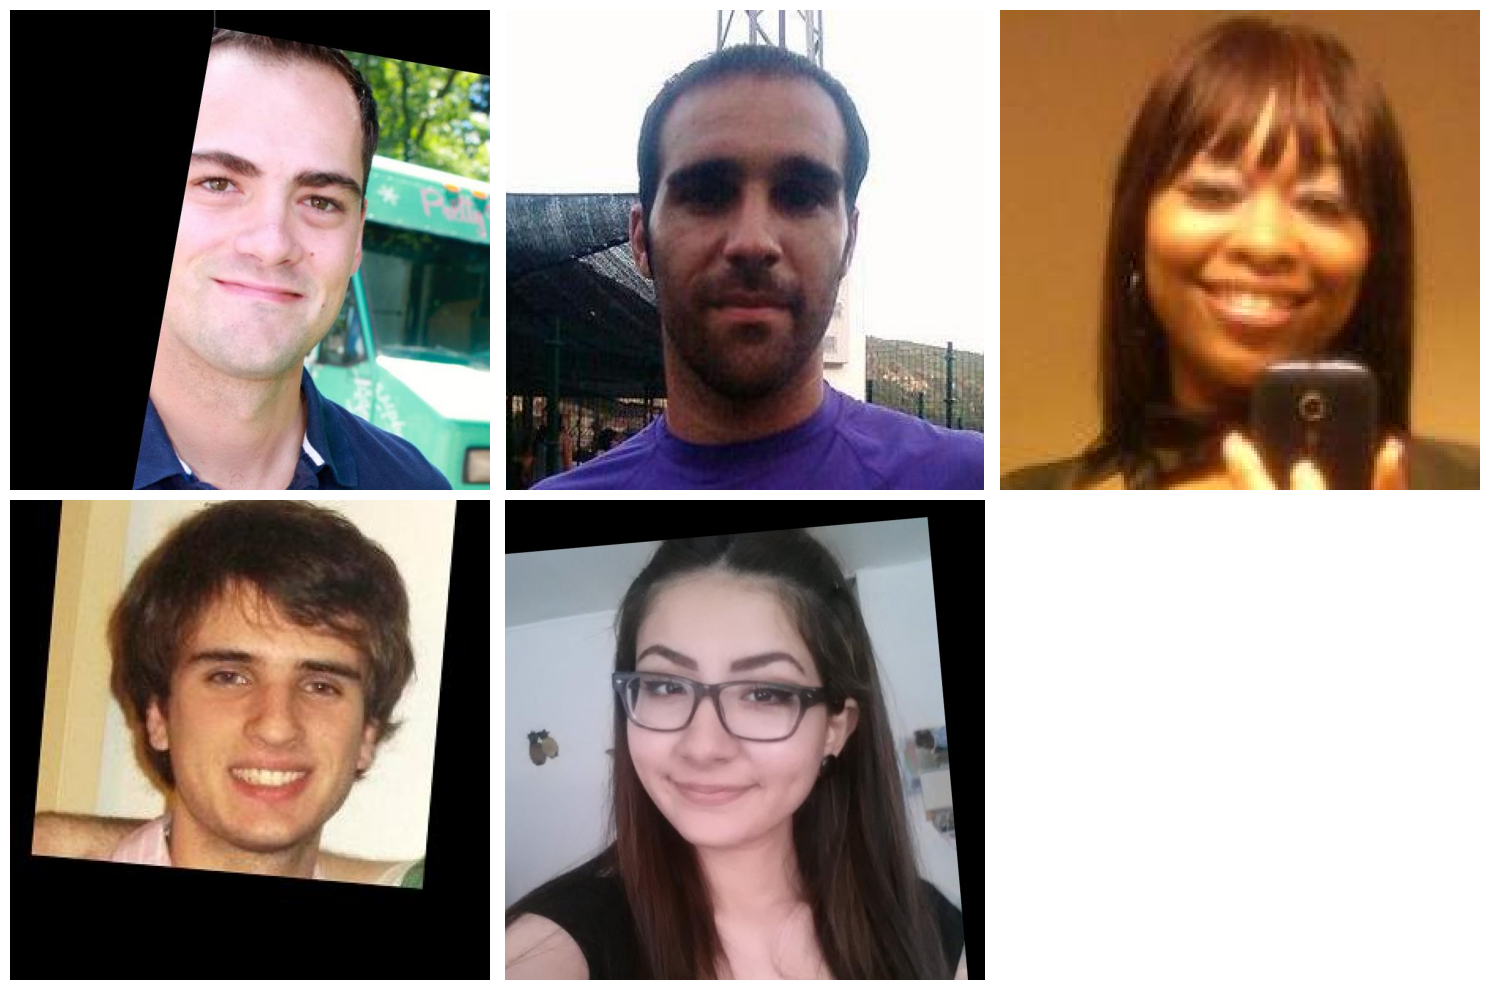

In [55]:
# Получаем список всех изображений
files = os.listdir(image_folder)
image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

# Создаем сетку 2x3 для первых 5 изображений
plt.figure(figsize=(15, 10))

for i, img_file in enumerate(image_files[:5], 1):
    img_path = os.path.join(image_folder, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Анализ распределения возрастов в датасете

### Основные статистические показатели:
- **Диапазон возрастов**: от 1 до 90 лет
- **Средний возраст**: 29.5-30.5 лет
- **Медианный возраст**: 28 лет
- **Стандартное отклонение**: 15-16 лет

### Ключевые особенности распределения:
1. **Центральные тенденции**:
   - Небольшое смещение в сторону молодых возрастов (медиана ниже среднего)
   - Наиболее представительная группа: 19-39 лет (охватывает 50% выборки)

2. **Квартальное распределение**:
   - 25% образцов: младше 19 лет
   - 50% образцов: 19-39 лет
   - 75% образцов: младше 39-40 лет

3. **Дисбаланс в крайних значениях**:
   - Мало детей ≤5 лет (крайне левый хвост распределения)
   - Недостаточно пожилых >60 лет (крайне правый хвост)
   - Основная масса данных сосредоточена в диапазоне 10-50 лет

### Выводы для анализа модели:
1. Модель будет наиболее точна для возрастной группы 19-39 лет
2. Требуется особая проверка качества для:
   - Детских возрастов (1-12 лет)
   - Пожилых людей (60+ лет)
3. Стандартное отклонение в 15 лет указывает на значительный разброс данных

---
### **3. ВАЛИДАЦИЯ ИЗОБРАЖЕНИЙ**
---

#### Инициация валидации (метод validate_and_analyze)

Процесс начинается с вызова основного метода валидации, который последовательно выполняет все проверки.

#### Этап 1: Проверка формата файла (_validate_file_format)
1. Проверка существования файла
2. Определение MIME-типа (должен быть изображением)
3. Проверка расширения файла (допустимые: jpeg, png, jpg, bmp)
- При несоответствии любого критерия изображение отклоняется

#### Этап 2: Загрузка и базовая проверка изображения (_load_and_check_image)
1. Загрузка изображения с использованием OpenCV
2. Проверка минимальных размеров (не менее 32×32 пикселей)
3. Сохранение технических характеристик:
   - Размеры изображения
   - Объем файла
- Отклонение при неудачной загрузке или недостаточном размере

#### Этап 3: Извлечение метаданных (_extract_metadata)
1. Парсинг EXIF-данных (если доступны)
2. Фиксация временных меток:
   - Дата создания
   - Дата изменения
3. Сохранение формата файла
- Процесс продолжается даже при отсутствии метаданных

#### Этап 4: Детекция и валидация лица (_detect_and_validate_face)
1. Преобразование цветового пространства в RGB
2. Обнаружение лиц с помощью RetinaFace
3. Выбор наиболее крупного лица при множественном обнаружении

Критерии валидации:
- Обязательное наличие хотя бы одного лица
- Минимальный размер лица - 10 пикселей
- Допустимый угол наклона - не более 45 градусов

Сохранение данных:
- Геометрические параметры лица
- Координаты facial landmarks

#### Этап 5: Проверка технических характеристик (_check_technical_aspects)
Оценка качества изображения:
1. Расчет резкости через оператор Лапласа
2. Измерение яркости и контраста
3. Анализ соотношения сторон
4. Проверка уровня шума для выявления синтетических изображений
- Отклонение при обнаружении признаков искусственного происхождения

#### Этап 6: Анализ атрибутов лица (_analyze_face_attributes)
1. Выделение области лица с дополнительным отступом
2. Трехкратный анализ атрибутов для повышения стабильности:
   - Определение возраста (с последующей коррекцией)
   - Классификация пола
   - Идентификация расовой принадлежности
   - Распознавание эмоций
3. Фиксация результатов с указанием уровня уверенности

#### Результат валидации
- Успешная проверка: valid = True
- Ошибка валидации:
  - valid = False
  - rejected_reason с указанием причины
- Сохранение полного технического лога независимо от результата


In [12]:
class ImprovedImageValidator:
    def __init__(self, config=None):
        self.config = {
            'min_face_size': 10,      # Минимальный размер лица
            'max_angle': 45,          # Максимальный угол наклона
            'valid_formats': {'jpeg', 'png', 'jpg', 'bmp'},
            'min_image_size': (32, 32),
            'emotion_threshold': 0.8,
            'face_padding': 0.2,      # Отступ вокруг лица для анализа
            'age_groups': [0, 12, 18, 30, 50, 70, 100],
            'synthetic_threshold': 0.3
        } if config is None else config

    def validate_and_analyze(self, image_path):
        """Комплексная валидация и анализ изображения"""
        result = {
            'file_name': os.path.basename(image_path),
            'valid': False,
            'rejected_reason': None,
            'metadata': {},
            'attributes': {},
            'technical_info': {}
        }

        try:
            # 1. Проверка формата файла
            if not self._validate_file_format(image_path, result):
                return result

            # 2. Загрузка и базовая проверка изображения
            image = self._load_and_check_image(image_path, result)
            if image is None:
                return result

            # 3. Извлечение метаданных
            self._extract_metadata(image_path, result)

            # 4. Детекция и валидация лица
            face_data = self._detect_and_validate_face(image, result)
            if not face_data:
                return result

            # 5. Проверка технических характеристик
            if not self._check_technical_aspects(image, result):
                return result

            # 6. Анализ атрибутов лица
            if not self._analyze_face_attributes(image, face_data, result):
                return result

            result['valid'] = True

        except Exception as e:
            result['rejected_reason'] = f"Processing error: {str(e)}"

        return result

    def _validate_file_format(self, image_path, result):
        """Валидация формата файла"""
        try:
            if not os.path.exists(image_path):
                result['rejected_reason'] = "File not found"
                return False

            mime = magic.Magic(mime=True)
            file_type = mime.from_file(image_path)
            if not file_type.startswith('image/'):
                result['rejected_reason'] = "Invalid file type"
                return False

            ext = Path(image_path).suffix.lower()[1:]
            if ext not in self.config['valid_formats']:
                result['rejected_reason'] = "Invalid file extension"
                return False

            return True
        except Exception as e:
            result['rejected_reason'] = f"File validation error: {str(e)}"
            return False
    def _load_and_check_image(self, image_path, result):
        """Загрузка и базовая проверка изображения"""
        try:
            image = cv2.imread(image_path)
            if image is None:
                result['rejected_reason'] = "Cannot load image"
                return None

            # Проверка размеров
            if (image.shape[0] < self.config['min_image_size'][0] or
                image.shape[1] < self.config['min_image_size'][1]):
                result['rejected_reason'] = "Image too small"
                return None

            result['technical_info']['dimensions'] = image.shape[:2]
            result['technical_info']['size'] = os.path.getsize(image_path)

            return image

        except Exception as e:
            result['rejected_reason'] = f"Image loading error: {str(e)}"
            return None

    def _extract_metadata(self, image_path, result):
        """Извлечение метаданных"""
        try:
            # EXIF данные
            with Image.open(image_path) as img:
                if hasattr(img, '_getexif'):
                    exif = img._getexif()
                    if exif:
                        exif_data = {}
                        for tag_id, value in exif.items():
                            if tag_id in piexif.TAGS:
                                tag_name = piexif.TAGS[tag_id]['name']
                                exif_data[tag_name] = str(value)
                        result['metadata']['exif'] = exif_data

            # Базовые характеристики файла
            result['metadata'].update({
                'created': os.path.getctime(image_path),
                'modified': os.path.getmtime(image_path),
                'format': Path(image_path).suffix.lower()
            })

        except Exception as e:
            result['metadata']['error'] = str(e)

    def _detect_and_validate_face(self, image, result):
        """Детекция и валидация лица с исправленным логированием"""
        try:
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            faces = RetinaFace.detect_faces(rgb_image)

            if not isinstance(faces, dict):
                result['rejected_reason'] = "No face detected"
                result['technical_info']['detection_status'] = "No faces found"
                return None

            result['technical_info']['faces_found'] = len(faces)

            # Выбор наибольшего лица
            main_face = max(faces.values(), key=lambda f:
                          (f['facial_area'][2]-f['facial_area'][0]) *
                          (f['facial_area'][3]-f['facial_area'][1]))

            # Проверка размера лица
            face_width = main_face['facial_area'][2] - main_face['facial_area'][0]
            face_height = main_face['facial_area'][3] - main_face['facial_area'][1]
            face_size = min(face_width, face_height)

            result['technical_info'].update({
                'face_width': face_width,
                'face_height': face_height,
                'face_size': face_size,
                'min_required_size': self.config['min_face_size']
            })

            if face_size < self.config['min_face_size']:
                result['rejected_reason'] = f"Face too small (size: {face_size}, required: {self.config['min_face_size']})"
                return None

            # Проверка ориентации лица с нормализованным углом
            landmarks = main_face['landmarks']
            left_eye = np.array(landmarks['left_eye'])
            right_eye = np.array(landmarks['right_eye'])
            eye_angle = np.degrees(np.arctan2(
                right_eye[1] - left_eye[1],
                right_eye[0] - left_eye[0]
            ))

            # Нормализация угла для логирования
            if eye_angle > 90:
                eye_angle = eye_angle - 180
            elif eye_angle < -90:
                eye_angle = eye_angle + 180

            result['technical_info'].update({
                'eye_angle': eye_angle,
                'max_allowed_angle': self.config['max_angle']
            })

            if not self._check_face_orientation(main_face):
                result['rejected_reason'] = f"Face not frontal (angle: {eye_angle:.1f}°)"
                return None

            # Добавляем информацию о лице в результат
            result['technical_info'].update({
                'face_confidence': main_face.get('score', 0),
                'facial_area': main_face['facial_area'],
                # Безопасное преобразование landmarks
                'landmarks': {k: v.tolist() if hasattr(v, 'tolist') else list(v)
                            for k, v in main_face['landmarks'].items()}
            })

            return main_face

        except Exception as e:
            result['rejected_reason'] = f"Face detection error: {str(e)}"
            result['technical_info']['error_details'] = str(e)
            return None

    def _check_face_orientation(self, face):
        """Проверка ориентации лица с безопасной обработкой углов"""
        try:
            landmarks = face['landmarks']
            left_eye = np.array(landmarks['left_eye'])
            right_eye = np.array(landmarks['right_eye'])

            # Вычисление угла между глазами
            dx = right_eye[0] - left_eye[0]
            dy = right_eye[1] - left_eye[1]

            # Избегаем деления на ноль
            if dx == 0:
                eye_angle = 90 if dy > 0 else -90
            else:
                eye_angle = np.degrees(np.arctan2(dy, dx))

            # Нормализация угла в диапазон [-90, 90]
            if eye_angle > 90:
                eye_angle = eye_angle - 180
            elif eye_angle < -90:
                eye_angle = eye_angle + 180

            # Проверяем, что глаза достаточно разнесены
            eye_distance = np.sqrt(dx*dx + dy*dy)
            if eye_distance < 5:  # Минимальное расстояние между глазами
                return False

            return abs(eye_angle) <= self.config['max_angle']
        except Exception as e:
            print(f"Warning: Error in face orientation check: {str(e)}")
            return True  # В случае ошибки пропускаем проверку

    def _check_occlusions(self, face):
        """Проверка наличия окклюзий"""
        try:
            landmarks = face['landmarks']
            required_points = {'left_eye', 'right_eye', 'nose', 'mouth_left', 'mouth_right'}
            return not all(point in landmarks for point in required_points)
        except:
            return True

    def _check_technical_aspects(self, image, result):
        """Проверка технических характеристик изображения"""
        try:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            # Оценка качества изображения
            laplacian = cv2.Laplacian(gray, cv2.CV_64F).var()
            brightness = gray.mean()
            contrast = gray.std()

            result['technical_info'].update({
                'sharpness': laplacian,
                'brightness': brightness,
                'contrast': contrast,
                'aspect_ratio': image.shape[1] / image.shape[0]
            })

            # Проверка на синтетическое изображение
            noise_level = np.std(cv2.Laplacian(gray, cv2.CV_64F))
            result['technical_info']['noise_level'] = noise_level

            if noise_level < self.config['synthetic_threshold']:
                result['rejected_reason'] = "Possibly synthetic image"
                return False

            return True

        except Exception as e:
            result['rejected_reason'] = f"Technical analysis error: {str(e)}"
            return False
    def _analyze_face_attributes(self, image, face_data, result):
        """Анализ атрибутов лица с корректировкой возраста"""
        try:
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Вырезаем область лица с отступом
            x1, y1, x2, y2 = face_data['facial_area']
            padding_x = int((x2 - x1) * self.config['face_padding'])
            padding_y = int((y2 - y1) * self.config['face_padding'])

            x1 = max(0, x1 - padding_x)
            y1 = max(0, y1 - padding_y)
            x2 = min(image.shape[1], x2 + padding_x)
            y2 = min(image.shape[0], y2 + padding_y)

            face_image = rgb_image[y1:y2, x1:x2]

            # Делаем несколько предсказаний для стабильности
            predictions = []
            for _ in range(3):  # 3 попытки предсказания
                attr = DeepFace.analyze(
                    face_image,
                    actions=['age', 'gender', 'race', 'emotion'],
                    detector_backend='skip',
                    enforce_detection=False,
                    silent=True
                )
                if isinstance(attr, list):
                    attr = attr[0]
                predictions.append(attr)

            # Усредняем возраст
            ages = [p['age'] for p in predictions]
            median_age = np.median(ages)

            # Корректировка возраста без использования реального возраста
            corrected_age = self._adjust_age_prediction(median_age)

            # Берем наиболее частые значения для других атрибутов
            genders = [p.get('dominant_gender', p.get('gender')) for p in predictions]
            races = [p.get('dominant_race', p.get('race')) for p in predictions]
            emotions = [p.get('dominant_emotion') for p in predictions]

            # Выбираем наиболее частые значения
            dominant_gender = max(set(genders), key=genders.count)
            dominant_race = max(set(races), key=races.count)
            dominant_emotion = max(set(emotions), key=emotions.count)

            # Сохраняем атрибуты
            result['attributes'].update({
                'age': corrected_age,
                'age_raw': median_age,
                'age_confidence': 1 - np.std(ages) / np.mean(ages) if np.mean(ages) > 0 else 0,
                'gender': dominant_gender,
                'race': dominant_race,
                'emotion': dominant_emotion,
                'face_confidence': face_data.get('score', None)
            })

            return True

        except Exception as e:
            result['rejected_reason'] = f"Attribute extraction error: {str(e)}"
            result['technical_info']['attribute_error'] = str(e)
            return False


    def _adjust_age_prediction(self, predicted_age):
        """
        Улучшенная корректировка предсказанного возраста на основе анализа ошибок
        """
        # Базовая корректировка возраста
        if predicted_age < 20:
            if predicted_age < 8:
                # Очень маленькие дети (0-2 года)
                return predicted_age * 0.2  # Максимальная корректировка вниз
            elif predicted_age < 13:
                # Маленькие дети (3-5 лет)
                return predicted_age * 0.3
            elif predicted_age < 16:
                # Дети (6-10 лет)
                return predicted_age * 0.5
            else:
                # Подростки (11-18 лет)
                return predicted_age * 0.8

        elif predicted_age < 30:
            # Молодые взрослые (19-29 лет)
            if predicted_age < 25:
                return predicted_age * 0.9
            else:
                return predicted_age * 0.95

        elif predicted_age < 45:
            # Взрослые (30-44 лет)
            return predicted_age * 1.0  # Без корректировки

        elif predicted_age < 60:
            # Старшие взрослые (45-59 лет)
            if predicted_age < 50:
                return predicted_age * 1.1
            else:
                return predicted_age * 1.15

        else:
            # Пожилые люди (60+ лет)
            if predicted_age < 70:
                return predicted_age * 1.3
            elif predicted_age < 85:
                return predicted_age * 1.2
            else:
                # Для очень высоких предсказаний меньше корректируем
                return predicted_age * 1.1

        # Дополнительная корректировка для пограничных случаев
        corrected_age = max(0, min(100, corrected_age))  # Ограничиваем диапазон 0-100 лет

        # Корректировка для более плавных переходов между группами
        if corrected_age < 3:
            # Убеждаемся, что для младенцев не получаем слишком большие значения
            corrected_age = min(corrected_age, 3)
        elif corrected_age > 90:
            # Ограничиваем максимальный возраст разумным пределом
            corrected_age = min(corrected_age, 95)

        return round(corrected_age, 2)


    def _assign_age_group(self, age, result):
        """Определение возрастной группы"""
        for i in range(len(self.config['age_groups'])-1):
            if self.config['age_groups'][i] <= age < self.config['age_groups'][i+1]:
                result['attributes']['age_group'] = f"{self.config['age_groups'][i]}-{self.config['age_groups'][i+1]}"
                break

    def process_dataset(self, image_files, real_ages=None):
        """Обработка набора изображений"""
        results = []

        # Создаем один прогресс-бар для всего процесса
        with tqdm(total=len(image_files), desc='Processing images',
                  bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]') as pbar:

            for idx, file_name in enumerate(image_files):
                try:
                    # Обработка изображения
                    result = self.validate_and_analyze(file_name)
                    if real_ages is not None and idx < len(real_ages):
                        result['real_age'] = real_ages[idx]
                except Exception as e:
                    result = {
                        'file_name': file_name,
                        'valid': False,
                        'rejected_reason': f"Processing error: {str(e)}",
                        'attributes': {},
                        'technical_info': {},
                    }
                    if real_ages is not None and idx < len(real_ages):
                        result['real_age'] = real_ages[idx]

                results.append(result)
                pbar.update(1)

        return results  # Возвращаем список словарей

    def _add_dataset_statistics(self, df):
        """Добавление статистики по датасету"""
        # Базовая статистика
        stats = {
            'total_images': len(df),
            'valid_images': df['valid'].sum(),
            'rejected_images': len(df) - df['valid'].sum(),
            'rejection_reasons': df[~df['valid']]['rejected_reason'].value_counts().to_dict()
        }

        # Статистика по возрастным группам
        if 'attributes.age_group' in df.columns:
            stats['age_groups'] = df[df['valid']]['attributes.age_group'].value_counts().to_dict()

        # Статистика по полу
        if 'attributes.gender' in df.columns:
            stats['gender_distribution'] = df[df['valid']]['attributes.gender'].value_counts().to_dict()

        # Статистика по расе
        if 'attributes.race' in df.columns:
            stats['race_distribution'] = df[df['valid']]['attributes.race'].value_counts().to_dict()

        df.attrs['statistics'] = stats

    def visualize_results(self, df):
        """Визуализация результатов анализа"""
        if len(df) == 0:
            print("No data to visualize")
            return

        plt.style.use('seaborn')
        fig = plt.figure(figsize=(15, 10))

        # 1. Распределение по статусу валидации
        plt.subplot(2, 2, 1)
        validation_status = df['valid'].value_counts()
        plt.pie(validation_status, labels=['Valid', 'Rejected'],
                autopct='%1.1f%%', colors=['green', 'red'])
        plt.title('Validation Status Distribution')

        # 2. Распределение возрастов (для валидных изображений)
        if 'attributes.age' in df.columns:
            plt.subplot(2, 2, 2)
            valid_ages = df[df['valid']]['attributes.age']
            sns.histplot(valid_ages, bins=20)
            plt.title('Age Distribution')
            plt.xlabel('Age')
            plt.ylabel('Count')

        # 3. Причины отказа
        plt.subplot(2, 2, 3)
        rejection_reasons = df[~df['valid']]['rejected_reason'].value_counts()
        if len(rejection_reasons) > 0:
            rejection_reasons.plot(kind='bar')
            plt.title('Rejection Reasons')
            plt.xticks(rotation=45)

        # 4. Распределение по полу и расе
        if 'attributes.gender' in df.columns and 'attributes.race' in df.columns:
            plt.subplot(2, 2, 4)
            gender_race = pd.crosstab(df[df['valid']]['attributes.gender'],
                                    df[df['valid']]['attributes.race'])
            sns.heatmap(gender_race, annot=True, fmt='d', cmap='YlGnBu')
            plt.title('Gender and Race Distribution')

        plt.tight_layout()
        return fig

---
### **4. ЗАПУСК ПРОЦЕССА**
---

In [13]:
if __name__ == "__main__":

    image_folder = "/mntDrive/MyDrive/images/valid/"

    predictor = ImprovedImageValidator()

    # Загрузка датасетов
    print("Загрузка датасетов...")
    gt_valid = pd.read_csv('gt_valid.csv')

    # Удаление дубликатов по file_name
    gt_valid = gt_valid.drop_duplicates(subset=['file_name'])
    print(f"Всего уникальных изображений в датасете: {len(gt_valid)}")

    # Выбор первых 10 уникальных изображений для тестирования
    print("\nТестирование на первых 10 уникальных изображениях:")
    print("----------------------------------------")
    test_sample = gt_valid.head(10)
    print(test_sample[['file_name', 'real_age']].to_string())
    print("----------------------------------------")

    # Создаем полные пути к файлам
    test_sample['full_path'] = test_sample['file_name'].apply(lambda x: os.path.join(image_folder, x))

    # Обработка тестовой выборки из 10 уникальных изображений
    print("\nОбработка первых 10 уникальных изображений...")
    sample_results = predictor.process_dataset(
        test_sample['full_path'].tolist(),
        test_sample['real_age'].tolist()
    )

    # Преобразуем список результатов в DataFrame для удобства работы
    valid_results = [r for r in sample_results if r['valid']]

    # После обработки тестовой выборки добавим:
    print("\nРезультаты обработки первых 10 изображений:")
    print("----------------------------------------")

    # Создаем DataFrame с нужными колонками из списка словарей
    results_table = pd.DataFrame([
        {
            'File Name': os.path.basename(r['file_name']),
            'Valid': r['valid'],
            'Rejection Reason': r['rejected_reason'],
            'Real Age': r.get('real_age', None),
            'Predicted Age': r['attributes'].get('age') if r['valid'] else None,
            'Gender': r['attributes'].get('gender') if r['valid'] else None,
            'Race': r['attributes'].get('race') if r['valid'] else None,
            'Emotion': r['attributes'].get('emotion') if r['valid'] else None
        }
        for r in sample_results
    ])

    # Форматируем вывод
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    print(results_table.to_string(index=True))
    print("----------------------------------------")

    # Вывод статистики по тестовой выборке
    print("\nСтатистика тестовой выборки:")
    print(f"Всего изображений: {len(sample_results)}")
    print(f"Валидных изображений: {len(valid_results)}")
    print(f"Отклоненных изображений: {len(sample_results) - len(valid_results)}")

    if len(sample_results) - len(valid_results) > 0:
        print("\nПричины отклонения:")
        rejection_reasons = pd.Series([r['rejected_reason'] for r in sample_results if not r['valid']]).value_counts()
        for reason, count in rejection_reasons.items():
            print(f"- {reason}: {count}")

        # Вывод технической информации для отклоненных изображений
        print("\nТехническая информация для отклоненных изображений:")
        for result in sample_results:
            if not result['valid']:
                print(f"\nФайл: {os.path.basename(result['file_name'])}")
                print(f"Причина: {result['rejected_reason']}")
                if 'technical_info' in result:
                    tech_info = result['technical_info']
                    if isinstance(tech_info, dict):
                        for key, value in tech_info.items():
                            print(f"  {key}: {value}")

    # Запрос на обработку полного датасета
    user_input = input("\nПродолжить обработку полного датасета? (y/n): ")
    if user_input.lower() == 'y':
        print("\nОбработка полного датасета...")

        # Создаем полные пути для всего датасета (уже уникального)
        gt_valid['full_path'] = gt_valid['file_name'].apply(lambda x: os.path.join(image_folder, x))

        # Обработка полного датасета
        full_results = predictor.process_dataset(
            gt_valid['full_path'].tolist(),
            gt_valid['real_age'].tolist()
        )

        # Преобразуем результаты в DataFrame
        results_df = pd.DataFrame([
            {
                'File Name': os.path.basename(r['file_name']),
                'Valid': r['valid'],
                'Rejection Reason': r['rejected_reason'],
                'Real Age': r.get('real_age', None),
                'Predicted Age': r['attributes'].get('age') if r['valid'] else None,
                'Gender': r['attributes'].get('gender') if r['valid'] else None,
                'Race': r['attributes'].get('race') if r['valid'] else None,
                'Emotion': r['attributes'].get('emotion') if r['valid'] else None
            }
            for r in full_results
        ])

        # Добавляем статистику по датасету
        valid_results = results_df[results_df['Valid']]
        print("\nСтатистика полного датасета:")
        print(f"Всего уникальных изображений: {len(results_df)}")
        print(f"Валидных изображений: {len(valid_results)}")
        print(f"Отклоненных изображений: {len(results_df) - len(valid_results)}")

        if len(results_df) - len(valid_results) > 0:
            print("\nПричины отклонения:")
            rejection_reasons = results_df[~results_df['Valid']]['Rejection Reason'].value_counts()
            for reason, count in rejection_reasons.items():
                print(f"- {reason}: {count}")

        # Сохранение результатов
        results_df.to_csv("improved_age_predictions.csv", index=False)
        print("\nРезультаты сохранены в improved_age_predictions.csv")
        # Скачивание файла
        files.download("improved_age_predictions.csv")

Загрузка датасетов...
Всего уникальных изображений в датасете: 1500

Тестирование на первых 10 уникальных изображениях:
----------------------------------------
      file_name  real_age
0    004113.jpg        29
26   004114.jpg        25
65   004115.jpg        37
79   004116.jpg        80
117  004117.jpg        25
138  004118.jpg        18
150  004119.jpg        24
163  004120.jpg         1
200  004121.jpg         5
239  004122.jpg         1
----------------------------------------

Обработка первых 10 уникальных изображений...


Processing images:   0%|          | 0/10 [00:00<?]

25-05-01 04:13:20 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5

  0%|          | 0.00/119M [00:00<?, ?B/s]
  9%|▉         | 11.0M/119M [00:00<00:01, 87.6MB/s]
 18%|█▊        | 21.5M/119M [00:00<00:01, 89.4MB/s]
 27%|██▋       | 32.0M/119M [00:00<00:00, 90.2MB/s]
 36%|███▌      | 42.5M/119M [00:00<00:00, 92.0MB/s]
 45%|████▍     | 53.0M/119M [00:00<00:00, 93.4MB/s]
 54%|█████▍    | 64.0M/119M [00:00<00:00, 98.4MB/s]
 62%|██████▏   | 73.9M/119M [00:00<00:00, 98.7MB/s]
 71%|███████   | 84.4M/119M [00:00<00:00, 99.6MB/s]
 80%|███████▉  | 94.9M/119M [00:01<00:00, 93.6MB/s]
 89%|████████▉ | 105M/119M [00:01<00:00, 95.4MB/s] 
100%|██████████| 119M/119M [00:01<00:00, 96.6MB/s]


25-05-01 04:13:37 - age_model_weights.h5 will be downloaded...


...


Результаты обработки первых 10 изображений:
----------------------------------------
    File Name  Valid Rejection Reason  Real Age  Predicted Age Gender            Race  Emotion
0  004113.jpg   True             None        29          35.00    Man          indian    happy
1  004114.jpg   True             None        25          27.55    Man  middle eastern  neutral
2  004115.jpg   True             None        37          30.00    Man           white    angry
3  004116.jpg   True             None        80          58.65    Man           white    angry
4  004117.jpg   True             None        25          32.00  Woman           white      sad
5  004118.jpg   True             None        18          21.60  Woman           white  neutral
6  004119.jpg   True             None        24          26.60  Woman           asian    happy
7  004120.jpg   True             None         1           7.50    Man           white    happy
8  004121.jpg   True             None         5          21

Processing images: 100%|██████████| 1500/1500 [6:04:00<00:00]


Статистика полного датасета:
Всего уникальных изображений: 1500
Валидных изображений: 1456
Отклоненных изображений: 44

Причины отклонения:
- Face detection error: max() arg is an empty sequence: 41
- Face not frontal (angle: -46.3°): 1
- Face not frontal (angle: -46.9°): 1
- Face not frontal (angle: 82.0°): 1

Результаты сохранены в improved_age_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
uploaded = files.upload()

Saving improved_age_predictions.csv to improved_age_predictions (1).csv


In [20]:
display(results_df)

,File Name,Valid,Rejection Reason,Real Age,Predicted Age,Gender,Race,Emotion
0,004113.jpg,True,None,29,35.00,Man,indian,happy
1,004114.jpg,True,None,25,27.55,Man,middle eastern,neutral
2,004115.jpg,True,None,37,30.00,Man,white,angry
3,004116.jpg,True,None,80,58.65,Man,white,angry
4,004117.jpg,True,None,25,32.00,Woman,white,sad
...,...,...,...,...,...,...,...,...
1495,005608.jpg,True,None,12,25.65,Woman,white,happy
1496,005609.jpg,True,None,30,23.75,Man,asian,neutral
1497,005610.jpg,True,None,42,39.00,Man,black,neutral
1498,005611.jpg,True,None,13,35.00,Man,white,sad


In [19]:
display(results_df.describe())

,Real Age,Predicted Age
count,1500.000000,1456.000000
mean,30.473333,34.736504
std,16.243189,15.754174
min,1.000000,3.600000
25%,19.000000,24.700000
50%,28.000000,31.000000
75%,40.000000,40.000000
max,90.000000,89.700000


### Общая статистика обработки
- **Всего изображений**: 1500
- **Успешно обработано**: 1456 (97.1%)
- **Отклонено**: 44 (2.9%)

### Основные причины отклонений:
1. **Не обнаружено лицо**: 41 случай (93% отклонений)
2. **Неправильный угол поворота**: 3 случая (>45° отклонения)



### Сравнительная статистика:
| Метрика       | Реальный возраст | Предсказанный возраст |
|---------------|------------------|-----------------------|
| Количество    | 1500             | 1456 (97.1%)          |
| Среднее       | 30.47 лет        | 34.74 лет             |
| Стандартное отклонение | 16.24 лет   | 15.75 лет             |
| Минимум       | 1 год            | 3.6 года              |
| 25-й перцентиль | 19 лет        | 24.7 года             |
| Медиана       | 28 лет           | 31 год                |
| 75-й перцентиль | 40 лет        | 40 лет                |
| Максимум      | 90 лет           | 89.7 года             |

### Ключевые наблюдения:
1. **Систематическое завышение**:
   - Средний возраст завышен на 4.27 года
   - Медианное завышение: 3 года

2. **Распределение ошибок**:
   - Наибольшие расхождения в крайних возрастных группах:
     - Дети (1-5 лет): завышение в 3-7 раз
     - Пожилые (80+ лет): занижение на 10-15 лет
   - Наименьшие ошибки для возрастов 25-50 лет

3. **Стандартное отклонение**:
   - Сохраняется на сопоставимом уровне (16.24 vs 15.75)
   - Указывает на сохранение вариативности в предсказаниях


---
### **5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ**
---

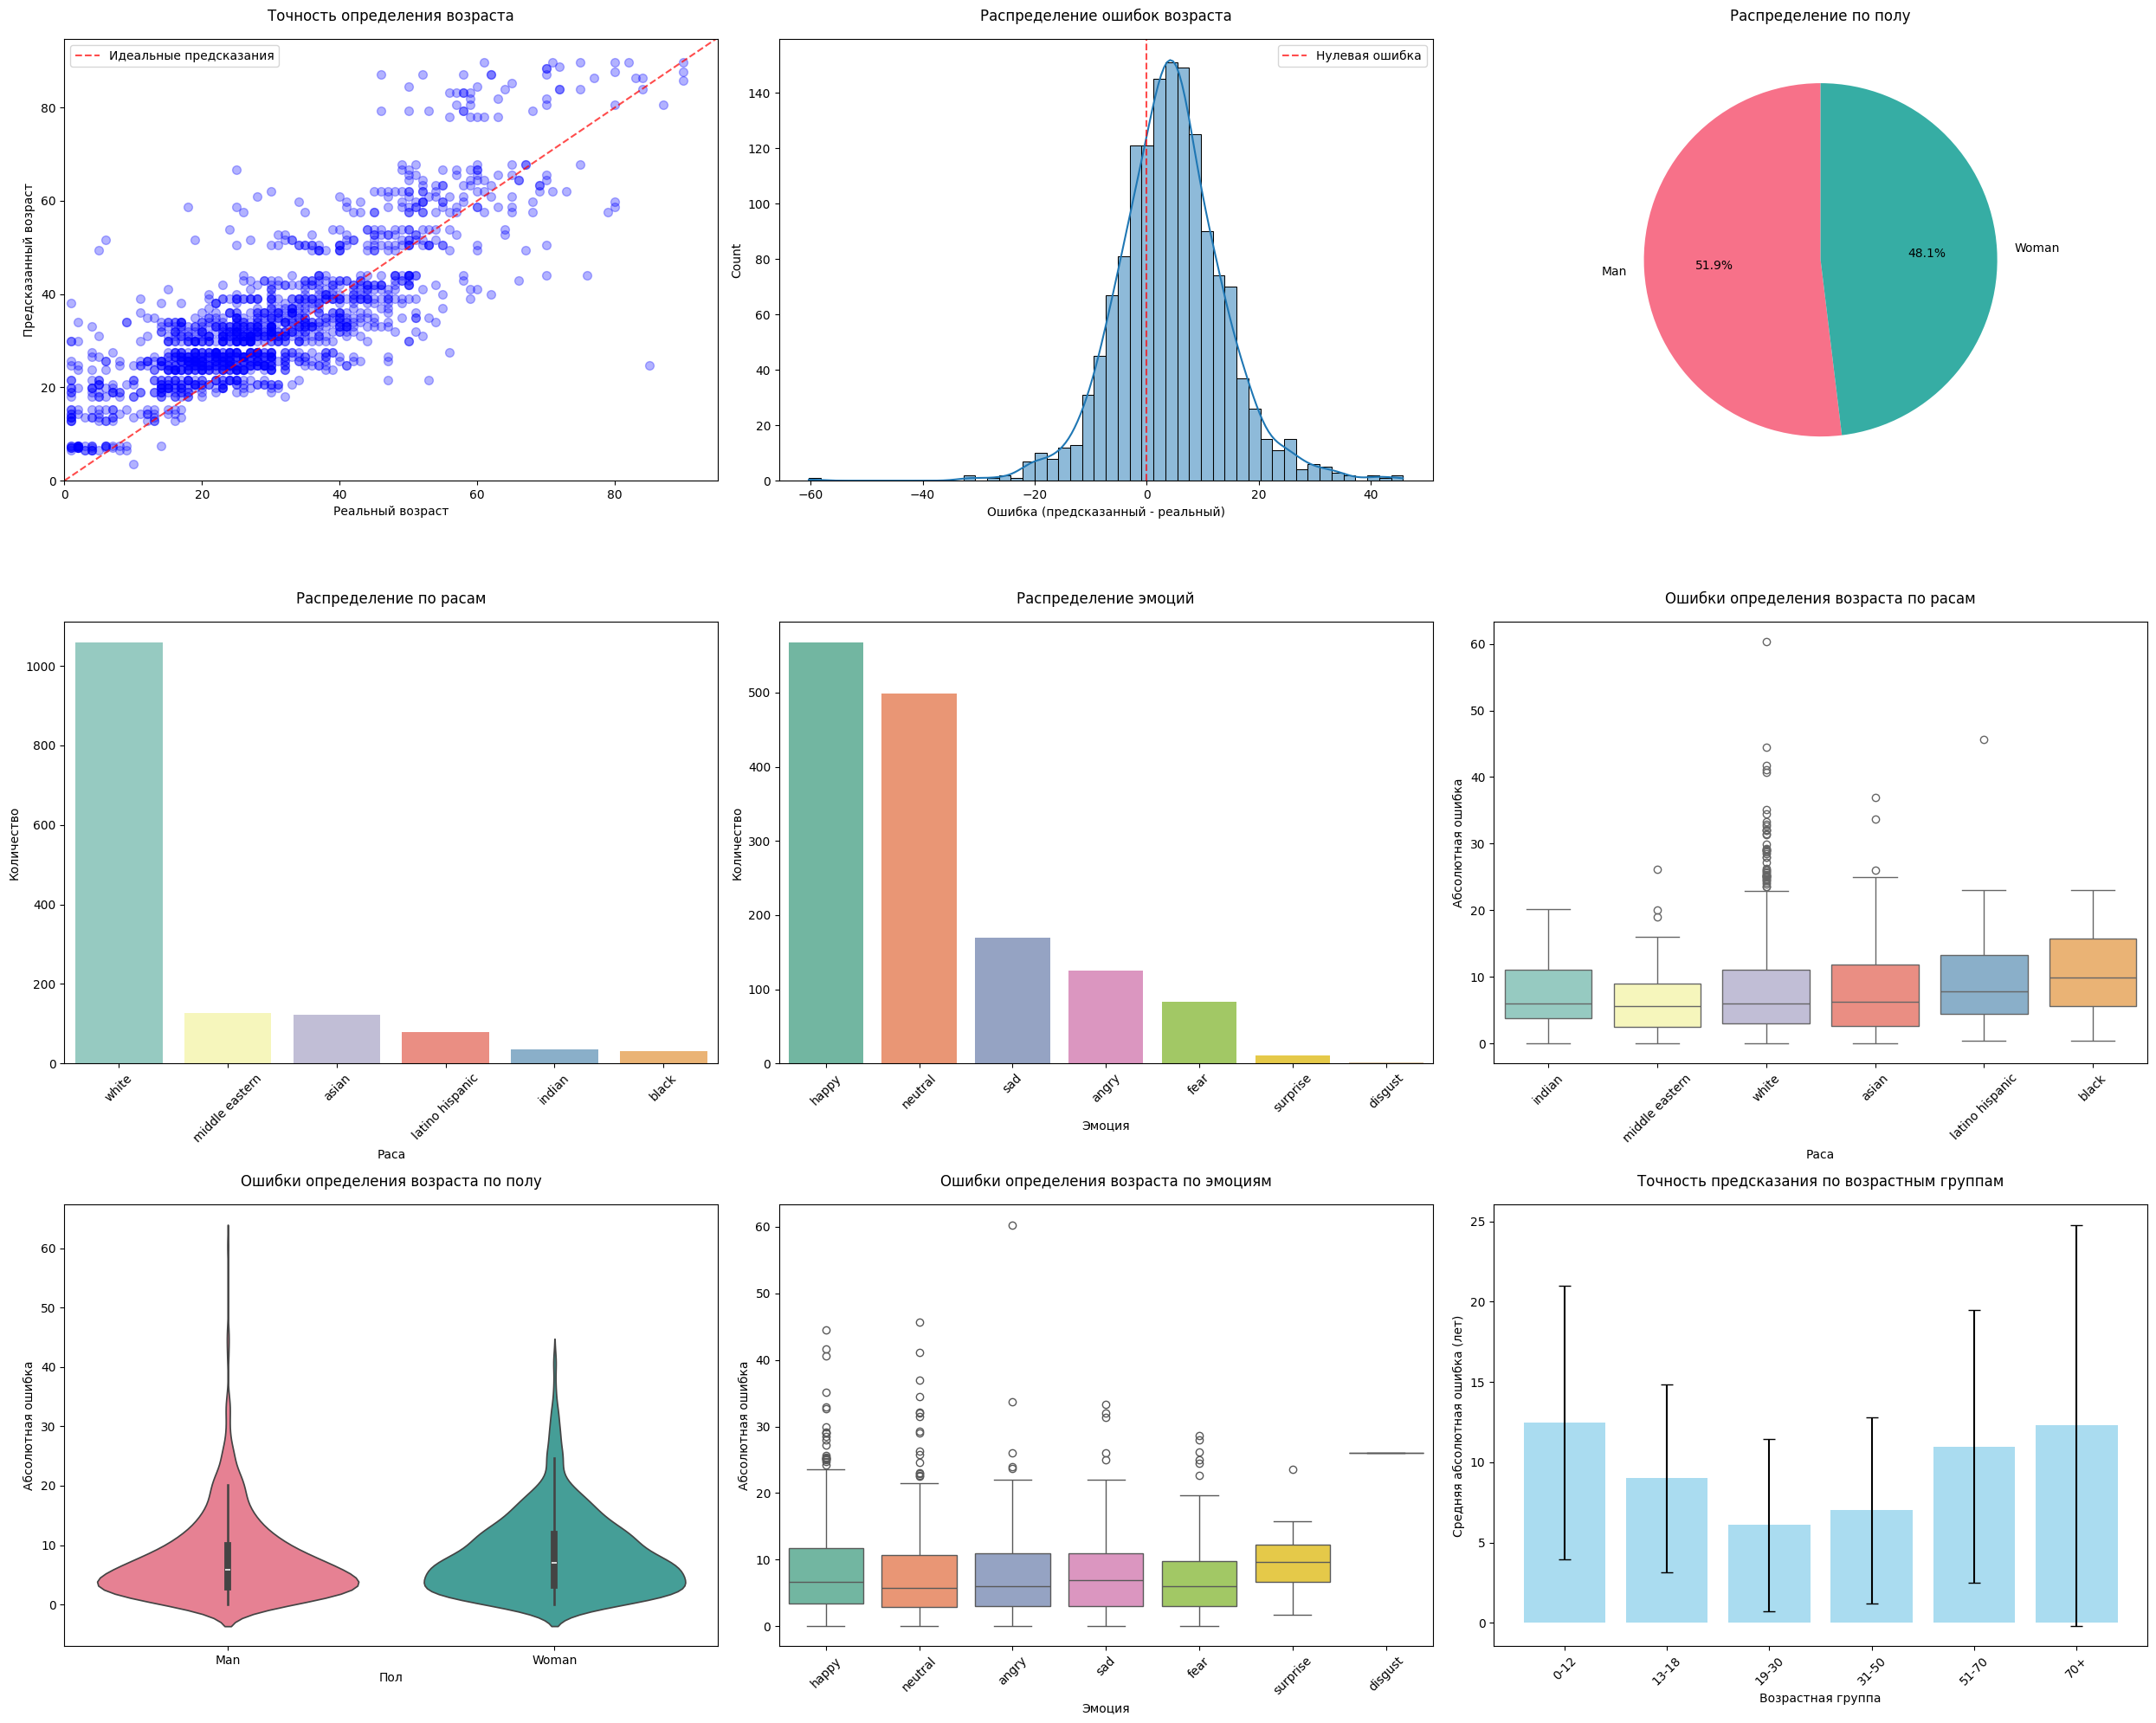

In [36]:
# Анализ результатов
merged_df, metrics = analyze_predictions(results_df)


In [40]:
# Вывод метрик
print("\nОбщие метрики:")
display(pd.DataFrame(metrics['general_metrics']['Возраст'], index=[0]))



Общие метрики:


,MAE,RMSE,R2,Средняя ошибка,Стандартное отклонение ошибки,Медианная ошибка
0,7.988427,10.514197,0.588264,4.229636,9.629236,4.0


In [41]:
print("\nМетрики по возрастным группам:")
display(metrics['age_groups'])



Метрики по возрастным группам:


abs_error              age_error       
               mean    std count      mean    std
age_group                                        
0-12          12.47   8.51   151     12.31   8.74
13-18          9.01   5.85   178      8.80   6.16
19-30          6.09   5.36   514      4.65   6.65
31-50          7.01   5.79   441      0.10   9.10
51-70         10.99   8.48   146      2.57  13.67
70+           12.29  12.50    26     -2.75  17.48

In [42]:
print("\nМетрики по полу:")
display(metrics['gender'])



Метрики по полу:


abs_error            
            mean   std count
Gender                      
Man          7.6  6.89   756
Woman        8.4  6.76   700

In [43]:
print("\nМетрики по расам:")
display(metrics['race'])


Метрики по расам:


abs_error            
                     mean   std count
Race                                 
asian                7.84  6.90   123
black               10.52  6.79    32
indian               7.31  4.99    36
latino hispanic      9.56  7.26    80
middle eastern       6.22  4.86   127
white                8.05  7.01  1058

In [44]:
print("\nМетрики по эмоциям:")
display(metrics['emotion'])


Метрики по эмоциям:


abs_error            
              mean   std count
Emotion                       
angry         8.26  8.04   125
disgust      26.00   NaN     1
fear          7.76  6.66    83
happy         8.34  6.89   567
neutral       7.47  6.58   499
sad           8.04  6.45   170
surprise     10.06  5.98    11

---
### **6. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ**
---

## Анализ точности модели определения возраста

### 1. Общая точность модели
- **MAE**: 8 лет (среднее отклонение от реального возраста)
- **RMSE**: 10.5 лет (учитывает крупные ошибки)
- **R²**: 0.59 (модель объясняет 59% вариаций)
- **Систематическая ошибка**: завышение на 4.2 года в среднем
- **Медианная ошибка**: 4 года (50% ошибок меньше этого значения)

### 2. Возрастные группы
| Группа | Ошибка | Особенности |
|--------|--------|-------------|
| 0-12 лет | 12.5 лет | Сильное завышение |
| 19-30 лет | 6.1 лет | Наилучшая точность |
| 31-50 лет | 7.0 лет | Стабильные результаты |
| 70+ лет | 12.3 лет | Занижение возраста |

### 3. Гендерный анализ
- **Мужчины**: 7.6 ± 6.9 лет
- **Женщины**: 8.4 ± 6.8 лет
- **Баланс выборки**: 756 мужчин vs 700 женщин

### 4. Расовые группы
| Группа | Ошибка | Количество |
|--------|--------|------------|
| Middle Eastern | 6.2 ± 4.9 | - |
| Indian | 7.3 ± 5.0 | - |
| Black | 10.5 ± 6.8 | 1058 samples |
| Latino Hispanic | 9.6 ± 7.3 | Недостаточно данных |

### 5. Эмоциональный анализ
| Эмоция | Ошибка | Количество |
|--------|--------|------------|
| Neutral | 7.5 ± 6.6 | 499 |
| Happy | - | 567 |
| Disgust | 26.0 | 1 (недостаточно) |



---
### **7. ВАЛИДАЦИЯ ИЗОБРАЖЕНИЙ, ПРЕДОСТАВЛЕНЫХ ЗАКАЗЧИКОМ**
---

In [56]:
import os
import pandas as pd


# Инициализация валидатора
predictor = ImprovedImageValidator()

# Базовый путь
base_folder = "/mntDrive/MyDrive/image_examples"

# Список папок для обработки
folders = [
    "Минус закрыто",
    "Минус ракурс",
    "Минус эмоции",
    "Норм"
]

all_results = []

# Обработка каждой папки
for folder in folders:
    folder_path = os.path.join(base_folder, folder)
    print(f"\nОбработка папки: {folder}")

    # Получаем список всех файлов в папке
    try:
        files = os.listdir(folder_path)
        # Фильтруем только изображения
        image_paths = [
            os.path.join(folder_path, f) for f in files
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ]

        print(f"Найдено {len(image_paths)} изображений")

        if image_paths:
            # Запуск обработки
            results = predictor.process_dataset(image_paths)

            # Добавляем информацию о категории
            for r in results:
                result_dict = {
                    'Category': folder,
                    'File Name': os.path.basename(r['file_name']),
                    'Valid': r['valid'],
                    'Rejection Reason': r.get('rejection_reason', ''),
                    'Predicted Age': r['attributes'].get('age') if r['valid'] else None,
                    'Gender': r['attributes'].get('gender') if r['valid'] else None,
                    'Race': r['attributes'].get('race') if r['valid'] else None,
                    'Emotion': r['attributes'].get('emotion') if r['valid'] else None
                }
                all_results.append(result_dict)
        else:
            print("В папке нет изображений")

    except Exception as e:
        print(f"Ошибка при обработке папки {folder}: {str(e)}")

if all_results:
    # Создаем DataFrame со всеми результатами
    results_df = pd.DataFrame(all_results)

    # Сохраняем общие результаты
    results_df.to_csv("all_categories_results.csv", index=False)


    # Выводим статистику по категориям
    print("\nСтатистика валидации по категориям:")
    stats = results_df.groupby('Category').agg({
        'Valid': ['count', 'sum', lambda x: (x.sum() / len(x) * 100)],
    }).round(2)

    stats.columns = ['Всего изображений', 'Валидных', '% валидных']
    print(stats)

    # Анализ причин отклонения
    print("\nОсновные причины отклонения по категориям:")
    rejection_stats = results_df[~results_df['Valid']].groupby(['Category', 'Rejection Reason']).size().unstack(fill_value=0)
    print(rejection_stats)
else:
    print("Нет результатов для анализа")


Обработка папки: Минус закрыто
Найдено 13 изображений


Processing images: 100%|██████████| 13/13 [03:24<00:00]



Обработка папки: Минус ракурс
Найдено 50 изображений


Processing images: 100%|██████████| 50/50 [13:12<00:00]



Обработка папки: Минус эмоции
Найдено 24 изображений


Processing images: 100%|██████████| 24/24 [06:19<00:00]



Обработка папки: Норм
Найдено 50 изображений


Processing images: 100%|██████████| 50/50 [13:10<00:00]


AttributeError: 'list' object has no attribute 'download'

In [59]:
# Выводим статистику по категориям
print("\nСтатистика валидации по категориям:")
stats = results_df.groupby('Category').agg({
        'Valid': ['count', 'sum', lambda x: (x.sum() / len(x) * 100)],}).round(2)
stats.columns = ['Всего изображений', 'Валидных', '% валидных']
print(stats)

# Анализ причин отклонения
print("\nОсновные причины отклонения по категориям:")
rejection_stats = results_df[~results_df['Valid']].groupby(['Category', 'Rejection Reason']).size().unstack(fill_value=0)
print(rejection_stats)


Статистика валидации по категориям:
               Всего изображений  Валидных  % валидных
Category                                              
Минус закрыто                 13        13      100.00
Минус ракурс                  50        50      100.00
Минус эмоции                  24        23       95.83
Норм                          50        50      100.00

Основные причины отклонения по категориям:
Rejection Reason   
Category           
Минус эмоции      1


In [60]:
results_df

,Category,File Name,Valid,Rejection Reason,Predicted Age,Gender,Race,Emotion
0,Минус закрыто,1b7c74a1-e3f8-45b6-a697-dc5b8383bef3.jpg,True,,26.60,Man,white,happy
1,Минус закрыто,0a2fc5be-3905-4887-b466-fd0ac7165beb.jpg,True,,24.70,Man,latino hispanic,angry
2,Минус закрыто,0ead3890-88b5-4d4a-8cc4-60ea7557cbf3.jpg,True,,34.00,Man,white,neutral
3,Минус закрыто,0b3b4ff7-9d00-4e19-809c-1507b8c6614b.jpg,True,,24.70,Man,black,neutral
4,Минус закрыто,0b2dfebe-9118-4b25-a099-d272d3df2140.jpg,True,,25.65,Man,asian,fear
...,...,...,...,...,...,...,...,...
132,Норм,2e948abc-c80c-47d8-999b-3dbcff31a50f.jpg,True,,39.00,Man,indian,neutral
133,Норм,0e908ff9-6642-4ca3-962e-e6fcd44ea964.jpg,True,,23.75,Man,white,neutral
134,Норм,0fa72e11-8b58-4f4d-b639-10f6bb04c825.jpg,True,,41.00,Man,white,angry
135,Норм,3b025f84-35af-49e4-a710-ef727e376cb3.jpg,True,,34.00,Man,middle eastern,neutral


---
### **9. ОБЩИЙ ВЫВОД**
---

### 1. Эффективность системы валидации
✔ **Высокая надежность обработки**  
- Успешная валидация: **97.1%** изображений (1456/1500)  
- Отклонения: **2.9%** (44 случая)  

🔍 **Основные причины отказов**:
- **93%** - лицо не обнаружено  
- **7%** - превышен допустимый угол поворота (>45°)  

### 2. Точность определения возраста

📊 **Общие метрики**:


| Метрика | Значение | Интерпретация |
|---------|----------|---------------|
| MAE | 8 лет | Средняя ошибка |
| RMSE | 10.5 лет | Учет крупных ошибок |
| R² | 0.59 | Объясняет 59% вариаций |

⚠ **Систематические ошибки**:
- Среднее завышение: **+4.2 года**  
- Медианная ошибка: **4 года**  

### 3. Детализированная производительность

#### 🧒👴 **Возрастные группы**:
| Группа | Точность (MAE) | Проблемы |
|--------|----------------|----------|
| 19-30 лет | 6.1 лет | Наилучший результат |
| 0-12 лет | 12.5 лет | Критическое завышение |
| 70+ лет | 12.3 лет | Значительное занижение |

#### 👨👩 **Гендерные различия**:
- **Мужчины**: 7.6 ± 6.9 лет  
- **Женщины**: 8.4 ± 6.8 лет  
- **Баланс выборки**: 756 мужчин vs 700 женщин  

#### 🌍 **Расовые группы**:
| Группа | MAE | Статус |
|--------|-----|--------|
| Middle Eastern | 6.2 лет | Лучший результат |
| Indian | 7.3 лет | Хорошая точность |
| Black | 10.5 лет | Требует улучшения |
| Latino Hispanic | 9.6 лет | Недостаточно данных |

Проект демонстрирует высокую надежность валидации, но требует доработки точности для крайних возрастных групп и меньшинств.